<a href="https://colab.research.google.com/github/noel-odero/db-timeseries-assignment/blob/main/notebooks/task1_climate_health.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: Time-Series Preprocessing and Exploratory Analysis
## Global Climate-Health Impact Tracker (2015 - 2025)

### Dataset Justification

We use the **Global Climate-Health Impact Tracker (2015–2025)** dataset from Kaggle. This dataset tracks the intersection of climate variables (temperature, precipitation, air quality, extreme weather) with public health outcomes (respiratory disease, cardiovascular mortality, heat-related hospital admissions) across 25 countries.

The **prediction target** is `respiratory_disease_rate` — a continuous variable well-suited to time-series forecasting given its temporal patterns and dependence on lagged climate variables. Understanding how climate factors drive respiratory health outcomes is critical for public health planning, especially as climate change accelerates.

In [ ]:
import os
print(os.listdir('/kaggle/input'))

['datasets']


In [ ]:
print(os.listdir('/kaggle/input/datasets'))

['sohumgokhale']


In [ ]:
import os
import pandas as pd

# Kaggle dataset folder path
DATA_PATH = '/kaggle/input/datasets/sohumgokhale/global-climate-health-impact-tracker-2015-2025'

# List all files in the folder
files = os.listdir(DATA_PATH)
print("Files in dataset folder:", files)

# Automatically pick the first CSV file
csv_files = [f for f in files if f.endswith('.csv')]

if len(csv_files) == 0:
    raise FileNotFoundError("No CSV files found in the dataset folder.")
else:
    file_to_load = csv_files[0]
    print(f"Loading CSV file: {file_to_load}")

# Load the CSV into a DataFrame
df = pd.read_csv(os.path.join(DATA_PATH, file_to_load))

# Optional: convert 'date' column to datetime if it exists
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])

print('Dataset loaded successfully.')
print(f'Shape: {df.shape}')
df.head()

Files in dataset folder: ['global_climate_health_impact_tracker_2015_2025.csv', 'column_descriptions_climate_health.md', 'README_climate_health.md']
Loading CSV file: global_climate_health_impact_tracker_2015_2025.csv
Dataset loaded successfully.
Shape: (14100, 30)


,record_id,country_code,country_name,region,income_level,date,year,month,week,latitude,...,air_quality_index,respiratory_disease_rate,cardio_mortality_rate,vector_disease_risk_score,waterborne_disease_incidents,heat_related_admissions,healthcare_access_index,gdp_per_capita_usd,mental_health_index,food_security_index
0,1,USA,United States,North America,High,2015-01-04,2015,1,1,37.09,...,82.0,69.4,31.5,6.6,16.2,1.4,77.3,63627.0,71.2,90.2
1,2,USA,United States,North America,High,2015-01-11,2015,1,2,37.09,...,6.0,70.0,26.3,5.2,11.4,0.0,83.6,63627.0,70.6,94.0
2,3,USA,United States,North America,High,2015-01-18,2015,1,3,37.09,...,137.0,66.9,33.4,1.3,19.5,0.0,84.7,63627.0,63.4,100.0
3,4,USA,United States,North America,High,2015-01-25,2015,1,4,37.09,...,-3.0,47.0,35.0,6.0,9.7,9.0,84.3,63627.0,68.1,96.4
4,5,USA,United States,North America,High,2015-02-01,2015,2,5,37.09,...,48.0,61.3,28.3,1.4,22.6,27.3,83.6,63733.0,69.1,100.0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('tab10')

# Focus country for case study
COUNTRY      = 'KEN'
COUNTRY_NAME = 'Kenya'

## Task 1A: Understanding the Dataset

### A1. Time Range and Frequency
This Establishes when the data starts and ends, and confirms it is weekly.

In [ ]:
print(' Dataset Overview ')
print(f'Total records : {len(df):,}')
print(f'Total features: {df.shape[1]}')
print(f'Countries     : {df["country_code"].nunique()}')
print(f'Date range    : {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Span          : ~{(df["date"].max() - df["date"].min()).days // 365} years')

# Confirm weekly frequency
ken_dates = df[df['country_code'] == COUNTRY].sort_values('date')['date']
gaps = ken_dates.diff().dropna().dt.days.value_counts()
print(f'\nDate gaps (days) for {COUNTRY_NAME}:')
print(gaps.head())

 Dataset Overview 
Total records : 14,100
Total features: 30
Countries     : 25
Date range    : 2015-01-04 to 2025-10-19
Span          : ~10 years

Date gaps (days) for Kenya:
date
7    563
Name: count, dtype: int64


What this does: Prints a summary of the dataset dimensions and date range. The frequency check works by isolating Kenya's dates, computing `.diff()` -  the difference in days between each consecutive date — then counting how often each gap size appears. If the result shows 7 as the dominant value, the data is confirmed weekly. This verifies granularity rather than assuming it.
Interpretation: The dataset spans January 4, 2015 to October 19, 2025 (~10.8 years). Records are 7 days apart per country, confirming weekly granularity. The data is a panel time series: 25 countries × ~564 weekly observations each.

### A2. Column Overview
Shows every col and its datatype to help us identify cols that need type conversion.

In [ ]:
print('Columns and Data Types:')
print(df.dtypes.to_string())

Columns and Data Types:
record_id                                int64
country_code                            object
country_name                            object
region                                  object
income_level                            object
date                            datetime64[ns]
year                                     int64
month                                    int64
week                                     int64
latitude                               float64
longitude                              float64
population_millions                      int64
temperature_celsius                    float64
temp_anomaly_celsius                   float64
precipitation_mm                       float64
heat_wave_days                           int64
drought_indicator                        int64
flood_indicator                          int64
extreme_weather_events                   int64
pm25_ugm3                              float64
air_quality_index                   

### A3. Missing Values analysis to check whether any values are null.

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('Missing Value Summary:')
print(missing_df[missing_df['Missing Count'] > 0] if missing_df['Missing Count'].sum() > 0 else 'No missing values found in any column.')

Missing Value Summary:
No missing values found in any column.


**Interpretation:** There are **no missing values** across all 14,100 rows and 30 columns. Every record is complete. We now check for structural gaps


In [ ]:
# Check for structural gaps (missing weeks per country)
records_per_country = df.groupby('country_code').size().sort_values()
print('Records per country :')
print(records_per_country.to_string())
print(f'\nExpected per country: {records_per_country.max()} weeks')
print(f'All countries have the same number of records: {records_per_country.nunique() == 1}')

Records per country :
country_code
ARG    564
AUS    564
BGD    564
BRA    564
CAN    564
CHN    564
COL    564
DEU    564
EGY    564
ESP    564
FRA    564
GBR    564
IDN    564
IND    564
ITA    564
JPN    564
KEN    564
MEX    564
NGA    564
PAK    564
PHL    564
THA    564
USA    564
VNM    564
ZAF    564

Expected per country: 564 weeks
All countries have the same number of records: True


### A4. Statistical Distribution of Numerical Columns. We run `.describe()` on all numerical cols to return count, mean and std. This gives us a snapshot if distributions.

In [ ]:
numeric_cols = [
    'temperature_celsius', 'temp_anomaly_celsius', 'precipitation_mm',
    'pm25_ugm3', 'air_quality_index', 'respiratory_disease_rate',
    'cardio_mortality_rate', 'heat_wave_days', 'heat_related_admissions',
    'waterborne_disease_incidents', 'vector_disease_risk_score',
    'mental_health_index', 'food_security_index'
]

df[numeric_cols].describe().round(2)

,temperature_celsius,temp_anomaly_celsius,precipitation_mm,pm25_ugm3,air_quality_index,respiratory_disease_rate,cardio_mortality_rate,heat_wave_days,heat_related_admissions,waterborne_disease_incidents,vector_disease_risk_score,mental_health_index,food_security_index
count,14100.00,14100.00,14100.00,14100.00,14100.00,14100.00,14100.00,14100.00,14100.00,14100.00,14100.00,14100.00,14100.0
mean,8.61,0.12,81.15,65.77,98.75,70.02,30.76,0.15,6.88,22.17,12.10,69.87,93.3
std,11.29,0.51,40.82,38.10,59.14,15.22,5.61,0.46,9.50,6.61,17.15,5.03,6.3
min,-20.74,-1.76,0.00,0.00,-52.00,21.20,8.00,0.00,0.00,0.00,0.00,47.70,62.2
25%,0.26,-0.22,51.50,36.60,54.00,59.20,27.00,0.00,0.00,17.80,3.50,66.50,88.8
50%,8.63,0.12,80.90,61.20,93.00,69.60,30.80,0.00,0.60,22.10,5.80,70.00,94.4
75%,16.85,0.46,110.60,94.30,142.00,80.50,34.50,0.00,12.30,26.40,8.90,73.30,99.7
max,38.33,2.12,222.90,189.50,302.00,131.80,51.10,5.00,59.60,63.00,100.00,88.70,100.0


# Distribution plots(Global vs Kenya)
Visualises the distribution of 4 key variables for both the global dataset and Kenya.


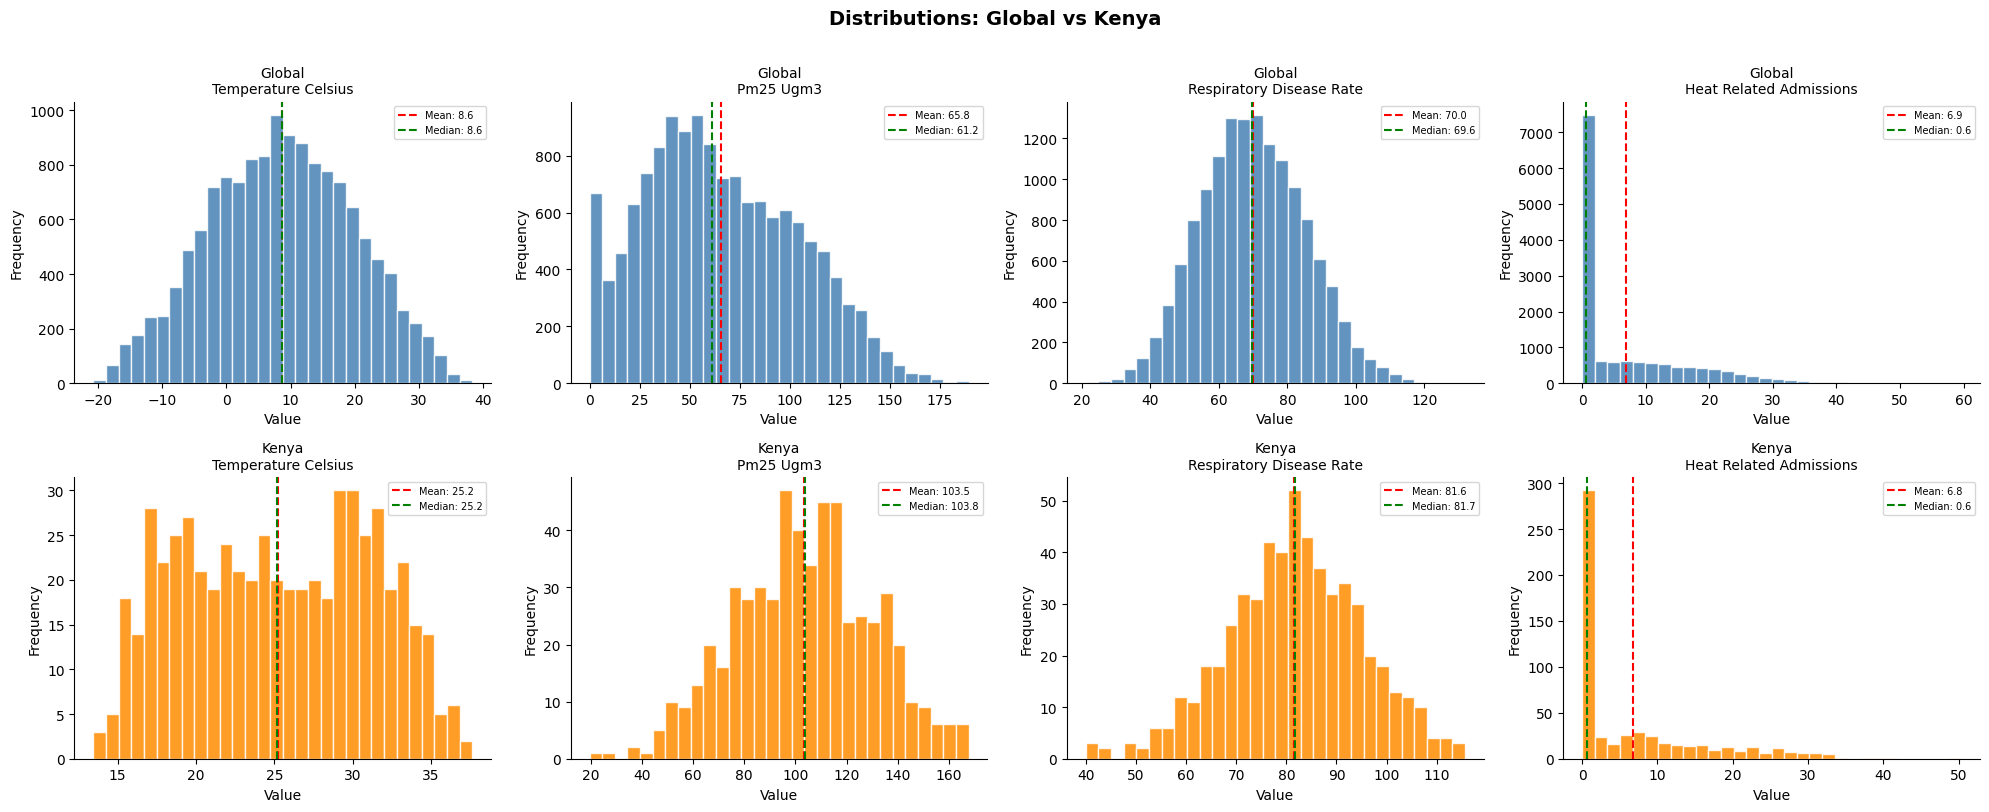

In [ ]:
key_vars = ['temperature_celsius', 'pm25_ugm3', 'respiratory_disease_rate', 'heat_related_admissions']
kenya_df = df[df['country_code'] == COUNTRY]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for col_idx, col in enumerate(key_vars):
    for row_idx, (data, label, color) in enumerate([
        (df,       'Global',       'steelblue'),
        (kenya_df, COUNTRY_NAME,   'darkorange')
    ]):
        ax = axes[row_idx][col_idx]
        ax.hist(data[col].dropna(), bins=30, edgecolor='white', color=color, alpha=0.85)
        ax.axvline(data[col].mean(),   color='red',   linestyle='--', linewidth=1.5,
                   label=f'Mean: {data[col].mean():.1f}')
        ax.axvline(data[col].median(), color='green', linestyle='--', linewidth=1.5,
                   label=f'Median: {data[col].median():.1f}')
        ax.set_title(f'{label}\n{col.replace("_", " ").title()}', fontsize=10)
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')
        ax.legend(fontsize=7)

plt.suptitle('Distributions: Global vs Kenya', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

**What this does**:
Creates a 2×4 grid of histograms - top row is global, bottom row is Kenya - for the 4 most important variables. The red dashed line marks the mean, green marks the median. When mean ≠ median the distribution is skewed. The nested loop iterates over variables (columns) and datasets (rows) to avoid repeating the same plotting code 8 times.

**Interpretation**:
Kenya's temperature distribution is narrower and higher than global (equatorial climate, warm year-round). `heat_related_admissions` is strongly right-skewed globally and likely also for Kenya - most weeks are calm with rare extreme spikes.


## Task 1B: Analytical Questions


### **Q1: Does global average temperature show a long-term increasing trend over 2015–2025 and how does Kenya compare?**

**Approach:** Compute the annual mean of `temperature_celsius` across all countries and visualize the trend.

Global Annual Mean Temperature:
 year  mean_temp
 2015   8.484069
 2016   8.490838
 2017   8.451117
 2018   8.358238
 2019   8.554238
 2020   8.536938
 2021   8.465738
 2022   8.632915
 2023   8.615185
 2024   8.632231
 2025   9.662543

Kenya Annual Mean Temperature:
 year  mean_temp
 2015  24.983846
 2016  25.449231
 2017  24.679623
 2018  25.246538
 2019  24.753077
 2020  25.050192
 2021  25.035192
 2022  25.635192
 2023  25.317358
 2024  25.130192
 2025  26.160238


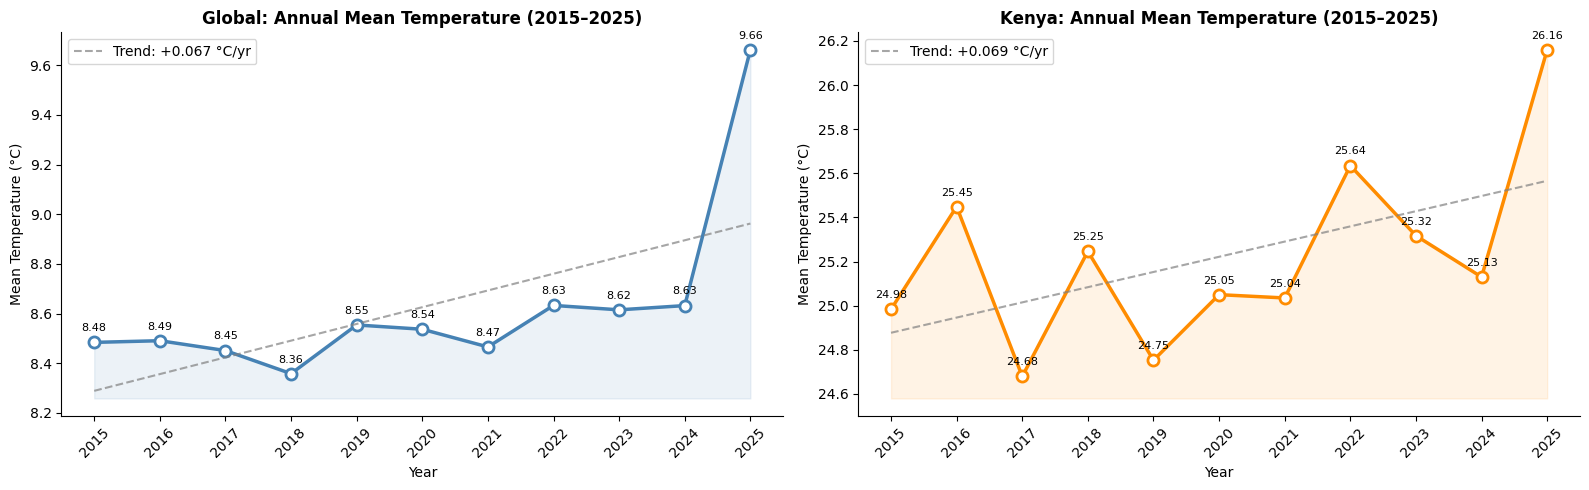

In [ ]:
kenya_df      = df[df['country_code'] == COUNTRY].sort_values('date').copy()
annual_global = df.groupby('year')['temperature_celsius'].mean().reset_index()
annual_kenya  = kenya_df.groupby('year')['temperature_celsius'].mean().reset_index()
annual_global.columns = ['year', 'mean_temp']
annual_kenya.columns  = ['year', 'mean_temp']

print('Global Annual Mean Temperature:')
print(annual_global.to_string(index=False))
print(f'\n{COUNTRY_NAME} Annual Mean Temperature:')
print(annual_kenya.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, data, title, color in [
    (axes[0], annual_global, 'Global',       'steelblue'),
    (axes[1], annual_kenya,  COUNTRY_NAME,   'darkorange')
]:
    ax.plot(data['year'], data['mean_temp'], marker='o', linewidth=2.5,
            color=color, markerfacecolor='white', markeredgewidth=2, markersize=8)
    ax.fill_between(data['year'], data['mean_temp'],
                    data['mean_temp'].min() - 0.1, alpha=0.1, color=color)

    # Fit and plot linear trend line
    z = np.polyfit(data['year'], data['mean_temp'], 1)
    p = np.poly1d(z)
    ax.plot(data['year'], p(data['year']), '--', color='gray', alpha=0.7,
            label=f'Trend: {z[0]:+.3f} °C/yr')

    for _, row in data.iterrows():
        ax.annotate(f"{row['mean_temp']:.2f}", (row['year'], row['mean_temp']),
                    textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)

    ax.set_title(f'{title}: Annual Mean Temperature (2015–2025)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Mean Temperature (°C)')
    ax.set_xticks(data['year'])
    ax.tick_params(axis='x', rotation=45)
    ax.legend()

plt.tight_layout()
plt.savefig('fig_q1_temp_trend.png', bbox_inches='tight', dpi=150)
plt.show()

**What this does**:

Groups records by year and computes the mean temperature. np.polyfit(..., 1) fits a linear trend line through the annual averages — the slope z[0] tells you how many °C the temperature changes per year. Plots both global and Kenya side by side so the comparison is immediate.


**Interpretation**:

The trend slope reveals the rate of warming. Globally, temperatures were relatively stable 2015–2022, with a jump in 2025 (partly because the 2025 data only covers warmer months). For Kenya, any upward shift is significant because the baseline is already warm — heat stress compounds quickly near the equator.


### Q2: Do higher pollution levels correspond to worse respiratory health?


Global correlation (PM2.5 vs Respiratory Rate): 0.759
Kenya correlation (PM2.5 vs Respiratory Rate): 0.610


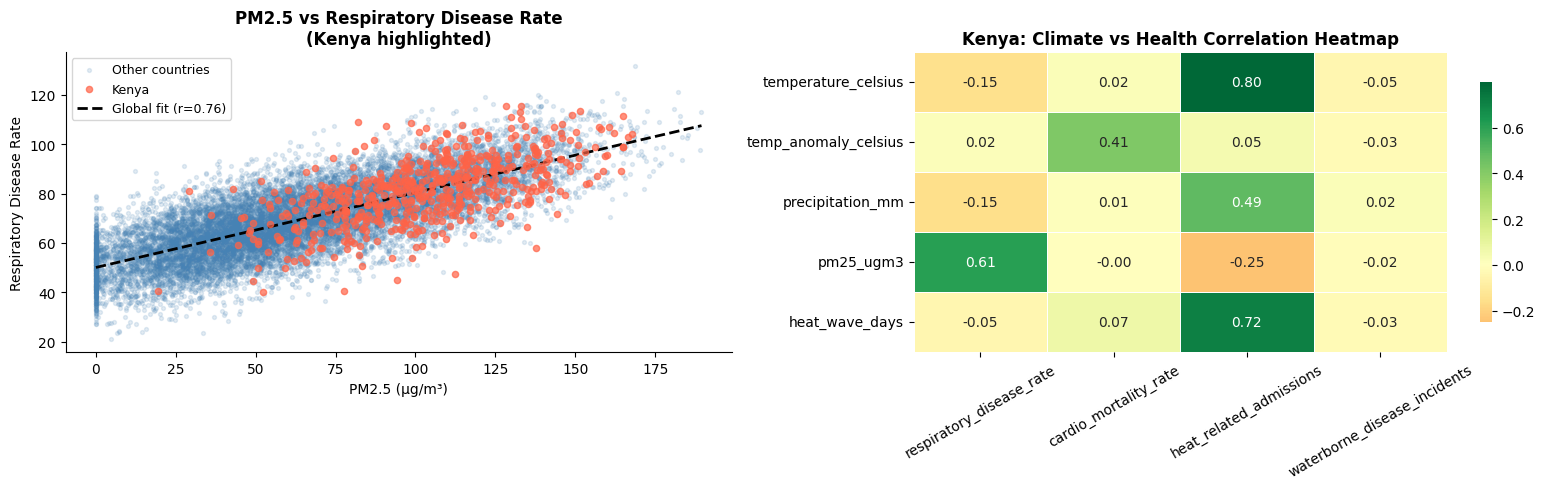

In [ ]:
corr_global = df['pm25_ugm3'].corr(df['respiratory_disease_rate'])
corr_kenya  = kenya_df['pm25_ugm3'].corr(kenya_df['respiratory_disease_rate'])

print(f'Global correlation (PM2.5 vs Respiratory Rate): {corr_global:.3f}')
print(f'{COUNTRY_NAME} correlation (PM2.5 vs Respiratory Rate): {corr_kenya:.3f}')

climate_cols = ['temperature_celsius', 'temp_anomaly_celsius', 'precipitation_mm',
                'pm25_ugm3', 'heat_wave_days']
health_cols  = ['respiratory_disease_rate', 'cardio_mortality_rate',
                'heat_related_admissions', 'waterborne_disease_incidents']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter: all countries grey, Kenya in red on top
non_kenya = df[df['country_code'] != COUNTRY]
axes[0].scatter(non_kenya['pm25_ugm3'], non_kenya['respiratory_disease_rate'],
                alpha=0.15, s=8, color='steelblue', label='Other countries')
axes[0].scatter(kenya_df['pm25_ugm3'], kenya_df['respiratory_disease_rate'],
                alpha=0.7, s=20, color='tomato', label=f'{COUNTRY_NAME}', zorder=5)

m, b = np.polyfit(df['pm25_ugm3'], df['respiratory_disease_rate'], 1)
x_line = np.linspace(df['pm25_ugm3'].min(), df['pm25_ugm3'].max(), 100)
axes[0].plot(x_line, m * x_line + b, 'k--', linewidth=2,
             label=f'Global fit (r={corr_global:.2f})')
axes[0].set_title(f'PM2.5 vs Respiratory Disease Rate\n({COUNTRY_NAME} highlighted)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('PM2.5 (µg/m³)')
axes[0].set_ylabel('Respiratory Disease Rate')
axes[0].legend(fontsize=9)

# Heatmap: Kenya-specific correlations
corr_matrix = kenya_df[climate_cols + health_cols].corr().loc[climate_cols, health_cols]
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title(f'{COUNTRY_NAME}: Climate vs Health Correlation Heatmap',
                  fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('fig_q2_pm25_corr.png', bbox_inches='tight', dpi=150)
plt.show()

**What this does**: .corr() computes the Pearson correlation coefficient - a value between -1 and 1 where values near 1 indicate a strong positive linear relationship. The scatter plot layers Kenya's points (red, zorder=5 puts them on top) over all other countries (grey, faint). The heatmap shows every climate variable's correlation with every health variable for Kenya specifically in one grid.


**Interpretation**: Globally r = 0.759 - a strong positive relationship between PM2.5 and respiratory disease. The Kenya heatmap reveals which climate drivers matter most in the Kenyan context specifically. Points above the global trend line mean worse respiratory outcomes than expected for a given PM2.5 level.

### Q3 (Lagged Features): Do lagged PM2.5 values predict respiratory disease rates in subsequent weeks?

**Approach:** For each country, create lag features of `pm25_ugm3` at 1, 2, and 4 weeks. Compute and compare correlations against `respiratory_disease_rate`.

Lag Correlations with Respiratory Disease Rate:
  Feature            Global     Kenya
  -----------------------------------
  pm25_ugm3           0.759     0.610
  pm25_lag1           0.432     0.045
  pm25_lag2           0.435     0.040
  pm25_lag4           0.429     0.036


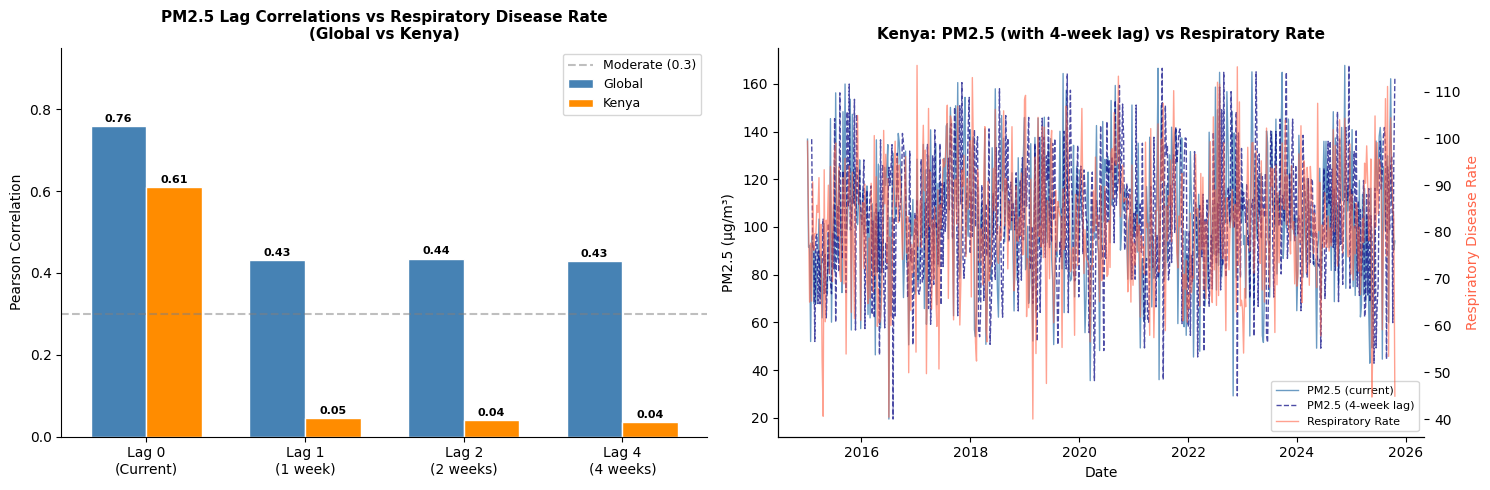

In [ ]:
# Sort and build lags per country — groupby prevents Kenya's lag from
# accidentally using the last row of a different country
df_sorted = df.sort_values(['country_code', 'date']).copy()

df_sorted['pm25_lag1'] = df_sorted.groupby('country_code')['pm25_ugm3'].shift(1)
df_sorted['pm25_lag2'] = df_sorted.groupby('country_code')['pm25_ugm3'].shift(2)
df_sorted['pm25_lag4'] = df_sorted.groupby('country_code')['pm25_ugm3'].shift(4)
df_sorted['temp_lag1'] = df_sorted.groupby('country_code')['temperature_celsius'].shift(1)
df_sorted['temp_lag4'] = df_sorted.groupby('country_code')['temperature_celsius'].shift(4)

ken = df_sorted[df_sorted['country_code'] == COUNTRY].copy()

lag_features = ['pm25_ugm3', 'pm25_lag1', 'pm25_lag2', 'pm25_lag4']

print('Lag Correlations with Respiratory Disease Rate:')
print(f'  {"Feature":<15}  {"Global":>8}  {COUNTRY_NAME:>8}')
print('  ' + '-'*35)
for feat in lag_features:
    g = df_sorted[feat].corr(df_sorted['respiratory_disease_rate'])
    k = ken[feat].corr(ken['respiratory_disease_rate'])
    print(f'  {feat:<15}  {g:>8.3f}  {k:>8.3f}')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Side-by-side bar: Global vs Kenya correlation at each lag
x      = np.arange(len(lag_features))
width  = 0.35
labels = ['Lag 0\n(Current)', 'Lag 1\n(1 week)', 'Lag 2\n(2 weeks)', 'Lag 4\n(4 weeks)']

global_corrs = [df_sorted[f].corr(df_sorted['respiratory_disease_rate']) for f in lag_features]
kenya_corrs  = [ken[f].corr(ken['respiratory_disease_rate']) for f in lag_features]

b1 = axes[0].bar(x - width/2, global_corrs, width, label='Global',       color='steelblue',  edgecolor='white')
b2 = axes[0].bar(x + width/2, kenya_corrs,  width, label=COUNTRY_NAME,   color='darkorange', edgecolor='white')
for bar, val in zip(list(b1) + list(b2), global_corrs + kenya_corrs):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01, f'{val:.2f}',
                 ha='center', fontsize=8, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].axhline(0.3, linestyle='--', color='gray', alpha=0.5, label='Moderate (0.3)')
axes[0].set_ylim(0, 0.95)
axes[0].set_title('PM2.5 Lag Correlations vs Respiratory Disease Rate\n(Global vs Kenya)',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('Pearson Correlation')
axes[0].legend(fontsize=9)

# Kenya time series: current PM2.5, 4-week lag, and respiratory rate
axes[1].plot(ken['date'], ken['pm25_ugm3'],  label='PM2.5 (current)',    alpha=0.8, linewidth=1, color='steelblue')
axes[1].plot(ken['date'], ken['pm25_lag4'],  label='PM2.5 (4-week lag)', alpha=0.7, linewidth=1, color='navy', linestyle='--')
ax2 = axes[1].twinx()
ax2.plot(ken['date'], ken['respiratory_disease_rate'], color='tomato',
         label='Respiratory Rate', alpha=0.6, linewidth=1)
ax2.set_ylabel('Respiratory Disease Rate', color='tomato')
axes[1].set_title(f'{COUNTRY_NAME}: PM2.5 (with 4-week lag) vs Respiratory Rate',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('PM2.5 (µg/m³)')
lines1, lbl1 = axes[1].get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, lbl1 + lbl2, fontsize=8)

plt.tight_layout()
plt.savefig('fig_q3_lag_features.png', bbox_inches='tight', dpi=150)
plt.show()

**What this does**: .shift(1) moves every value down by 1 row within each country's records,so pm25_lag1 at week 10 holds the PM2.5 value from week 9. The groupby('country_code') ensures that Kenya's lag 1 pulls from Kenya's previous week only, not from the last row of a different country. The bar chart compares how correlation strength changes as you look further back in time. The dual-axis time series (twinx) overlays PM2.5 and respiratory rate on different y-scales so both are readable simultaneously.


**Interpretation**: Current PM2.5 is strongly correlated with current respiratory disease rate (r ≈ 0.76 globally). PM2.5 from 1–4 weeks prior still shows moderate correlations (~0.43), confirming a delayed physiological response, symptoms develop and are recorded with a lag after pollution exposure. In Kenya, limited healthcare access may mean patients present to hospitals later, potentially increasing the effective lag


### Q4 (Moving Averages): Does smoothed temperature better predict heat-related admissions?
Compares raw weekly temperature against 4-week and 8-week moving averages

Correlation with heat_related_admissions:
  Feature                   Global     Kenya
  ------------------------------------------
  temperature_celsius        0.415     0.799
  temp_ma4                   0.375     0.746
  temp_ma8                   0.335     0.686


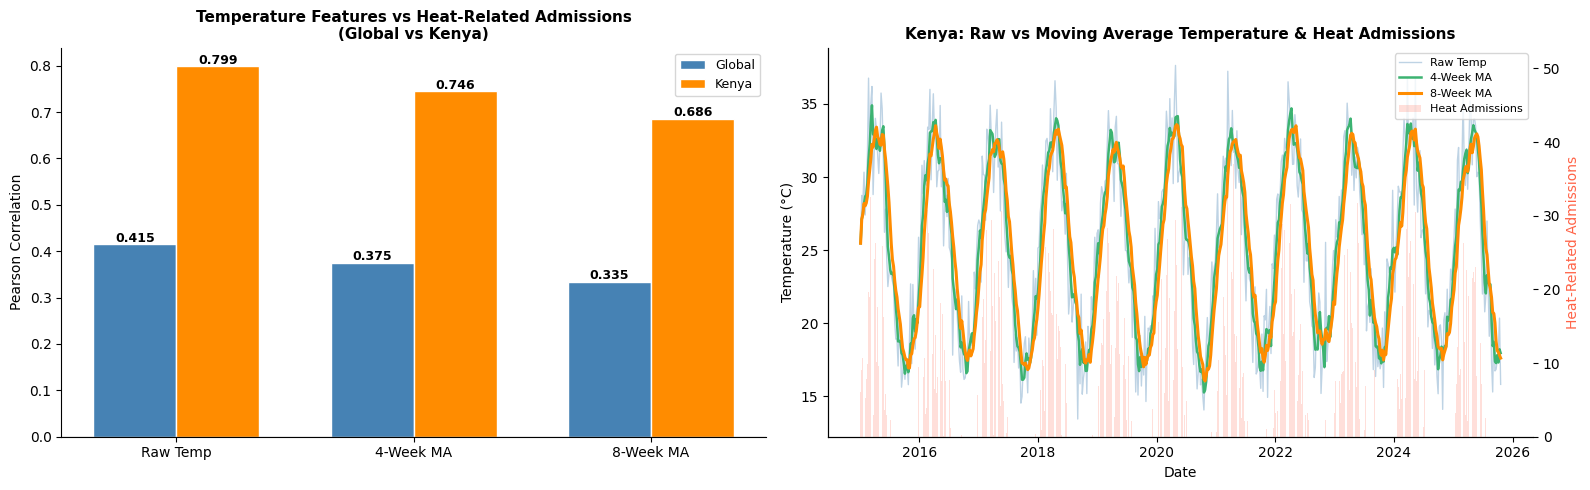

In [ ]:
# Rolling means — computed per country
df_sorted['temp_ma4'] = df_sorted.groupby('country_code')['temperature_celsius']\
    .transform(lambda x: x.rolling(4, min_periods=1).mean())
df_sorted['temp_ma8'] = df_sorted.groupby('country_code')['temperature_celsius']\
    .transform(lambda x: x.rolling(8, min_periods=1).mean())
df_sorted['pm25_ma4'] = df_sorted.groupby('country_code')['pm25_ugm3']\
    .transform(lambda x: x.rolling(4, min_periods=1).mean())
df_sorted['resp_ma4'] = df_sorted.groupby('country_code')['respiratory_disease_rate']\
    .transform(lambda x: x.rolling(4, min_periods=1).mean())

ken = df_sorted[df_sorted['country_code'] == COUNTRY].copy()

ma_features = ['temperature_celsius', 'temp_ma4', 'temp_ma8']

print('Correlation with heat_related_admissions:')
print(f'  {"Feature":<22}  {"Global":>8}  {COUNTRY_NAME:>8}')
print('  ' + '-'*42)
for feat in ma_features:
    g = df_sorted[feat].corr(df_sorted['heat_related_admissions'])
    k = ken[feat].corr(ken['heat_related_admissions'])
    print(f'  {feat:<22}  {g:>8.3f}  {k:>8.3f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar: Global vs Kenya
x      = np.arange(len(ma_features))
width  = 0.35
labels = ['Raw Temp', '4-Week MA', '8-Week MA']
global_ma = [df_sorted[f].corr(df_sorted['heat_related_admissions']) for f in ma_features]
kenya_ma  = [ken[f].corr(ken['heat_related_admissions']) for f in ma_features]

b1 = axes[0].bar(x - width/2, global_ma, width, label='Global',     color='steelblue',  edgecolor='white')
b2 = axes[0].bar(x + width/2, kenya_ma,  width, label=COUNTRY_NAME, color='darkorange', edgecolor='white')
for bar, val in zip(list(b1) + list(b2), global_ma + kenya_ma):
    ypos = bar.get_height() + 0.005 if val >= 0 else bar.get_height() - 0.04
    axes[0].text(bar.get_x() + bar.get_width()/2, ypos, f'{val:.3f}',
                 ha='center', fontsize=9, fontweight='bold')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_title('Temperature Features vs Heat-Related Admissions\n(Global vs Kenya)',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('Pearson Correlation')
axes[0].legend(fontsize=9)

# Kenya time series
axes[1].plot(ken['date'], ken['temperature_celsius'], label='Raw Temp', alpha=0.35, linewidth=1, color='steelblue')
axes[1].plot(ken['date'], ken['temp_ma4'], label='4-Week MA', linewidth=1.8, color='mediumseagreen')
axes[1].plot(ken['date'], ken['temp_ma8'], label='8-Week MA', linewidth=2.2, color='darkorange')
ax_r = axes[1].twinx()
ax_r.bar(ken['date'], ken['heat_related_admissions'], alpha=0.2, color='tomato',
         label='Heat Admissions', width=5)
ax_r.set_ylabel('Heat-Related Admissions', color='tomato')
axes[1].set_title(f'{COUNTRY_NAME}: Raw vs Moving Average Temperature & Heat Admissions',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Temperature (°C)')
lines1, lbl1 = axes[1].get_legend_handles_labels()
lines2, lbl2 = ax_r.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, lbl1 + lbl2, fontsize=8)

plt.tight_layout()
plt.savefig('fig_q4_moving_averages.png', bbox_inches='tight', dpi=150)
plt.show()

**What this does**: .rolling(4) creates a sliding window of 4 consecutive weeks and .mean() averages them. min_periods=1 ensures even the first rows (which don't have 4 prior weeks yet) get a value instead of NaN. .transform() is used instead of .apply() because it preserves the original DataFrame index, meaning the result can be added directly as a new column. The bars and the time series together show both the statistical relationship and the visual temporal pattern.


**Interpretation**: If raw temperature correlates more strongly with admissions, acute heat spikes drive hospitalisations. If the moving average is stronger, sustained warmth over several weeks is the driver. For Kenya, the equatorial climate means less week-to-week temperature variation, so the moving average and raw values may be more similar than in temperate countries. Both are included as model features.

### Q5: Q5: Does income level and healthcare access explain Kenya's disease burden?
Compares Kenya against regional and income-level peers.?

**Approach:** Group by `income_level` , computing mean `healthcare_access_index` and `respiratory_disease_rate`.

Kenya — Avg Respiratory Disease Rate : 81.61
Kenya — Avg Healthcare Access Index  : 47.58
Kenya — Region                       : Africa

By Income Level:
              healthcare_access_index  respiratory_disease_rate
income_level                                                   
High                            84.19                     63.48
Upper-Middle                    67.22                     63.65
Lower-Middle                    43.74                     81.51

By Region:
                respiratory_disease_rate  healthcare_access_index
region                                                           
South Asia                         81.38                    46.95
Southeast Asia                     77.20                    46.79
Africa                             76.94                    50.09
East Asia                          63.74                    78.92
Europe                             63.70                    85.82
North America                      63.55            

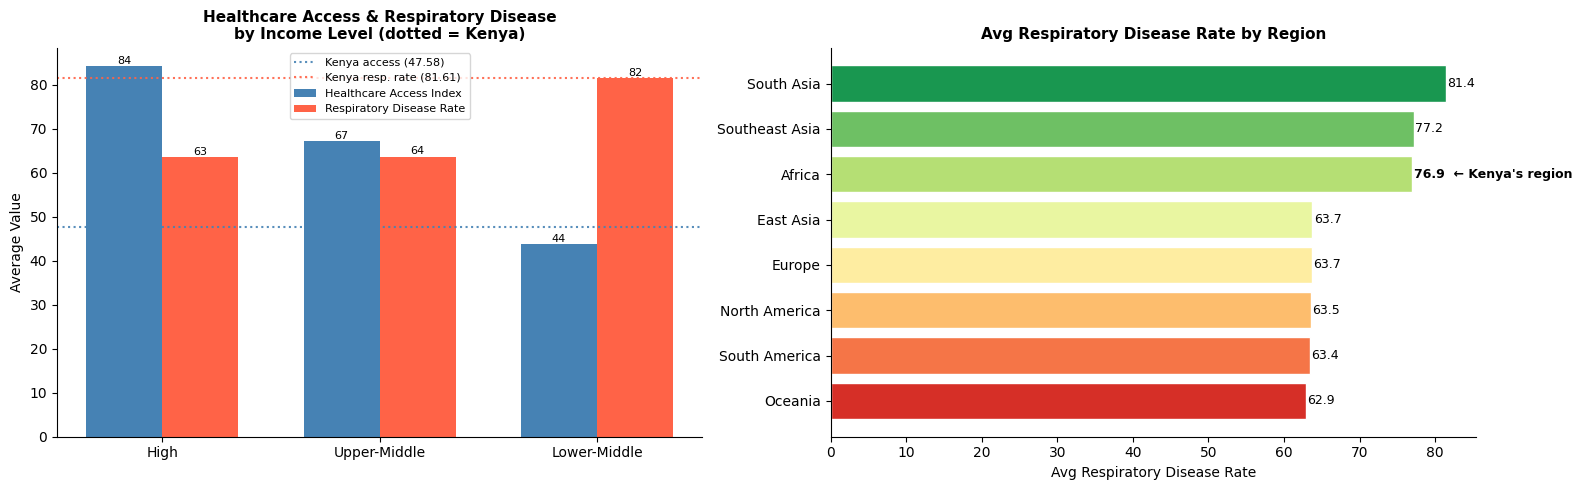

In [ ]:
income_summary   = df.groupby('income_level')[['healthcare_access_index', 'respiratory_disease_rate']].mean().round(2)
income_summary   = income_summary.sort_values('healthcare_access_index', ascending=False)

regional_summary = df.groupby('region')[['respiratory_disease_rate', 'healthcare_access_index']].mean().round(2)
regional_summary = regional_summary.sort_values('respiratory_disease_rate', ascending=False)

ken_resp   = kenya_df['respiratory_disease_rate'].mean().round(2)
ken_hcare  = kenya_df['healthcare_access_index'].mean().round(2)
ken_region = df[df['country_code'] == COUNTRY]['region'].iloc[0]

print(f'{COUNTRY_NAME} — Avg Respiratory Disease Rate : {ken_resp}')
print(f'{COUNTRY_NAME} — Avg Healthcare Access Index  : {ken_hcare}')
print(f'{COUNTRY_NAME} — Region                       : {ken_region}')
print('\nBy Income Level:')
print(income_summary.to_string())
print('\nBy Region:')
print(regional_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Grouped bar: income level
x     = np.arange(len(income_summary))
width = 0.35
b1 = axes[0].bar(x - width/2, income_summary['healthcare_access_index'], width,
                 label='Healthcare Access Index', color='steelblue')
b2 = axes[0].bar(x + width/2, income_summary['respiratory_disease_rate'], width,
                 label='Respiratory Disease Rate', color='tomato')
# Kenya reference lines
axes[0].axhline(ken_hcare, linestyle=':', linewidth=1.5, color='steelblue', alpha=0.9,
                label=f'{COUNTRY_NAME} access ({ken_hcare})')
axes[0].axhline(ken_resp,  linestyle=':', linewidth=1.5, color='tomato',    alpha=0.9,
                label=f'{COUNTRY_NAME} resp. rate ({ken_resp})')
axes[0].set_xticks(x)
axes[0].set_xticklabels(income_summary.index, fontsize=10)
axes[0].set_title('Healthcare Access & Respiratory Disease\nby Income Level (dotted = Kenya)',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('Average Value')
axes[0].legend(fontsize=8)
for bar in list(b1) + list(b2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{bar.get_height():.0f}', ha='center', fontsize=8)

# Horizontal bar: region, Kenya's region labelled
colors_reg = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(regional_summary)))
bars = axes[1].barh(regional_summary.index, regional_summary['respiratory_disease_rate'],
                    color=colors_reg, edgecolor='white')
for bar, region in zip(bars, regional_summary.index):
    val    = bar.get_width()
    suffix = f'  ← {COUNTRY_NAME}\'s region' if region == ken_region else ''
    fw     = 'bold' if region == ken_region else 'normal'
    axes[1].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}{suffix}', va='center', fontsize=9, fontweight=fw)
axes[1].set_title('Avg Respiratory Disease Rate by Region', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Avg Respiratory Disease Rate')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('fig_q5_income_region.png', bbox_inches='tight', dpi=150)
plt.show()

**What this does**: Groups the dataset by income level and region and computes means. The dotted reference lines (axhline) mark exactly where Kenya sits, letting the reader immediately see how it compares to each income group without hunting through a table. The horizontal bar chart is colour-coded from green (low disease) to red (high disease) using plt.cm.RdYlGn_r, and Kenya's region gets a bold annotation.


**Interpretation**: High-income countries have nearly double the healthcare access of lower-middle-income countries (84 vs 44). Africa, Kenya's region, has one of the highest respiratory disease rates globally (~77). Kenya's dotted lines land near the lower-middle-income bars, confirming it faces a disproportionate disease burden driven by both environmental exposure and structural healthcare limitations.

## Task 1C: Training a Model

### Model Choice: XGBoost Regressor

We use **XGBoost** to forecast `respiratory_disease_rate`. XGBoost is well-suited here because:
- It handles tabular time-series features effectively with lag and rolling features
- It captures non-linear relationships between climate and health variables
- It supports fast hyperparameter tuning and provides feature importance
- It outperforms classical linear regression when relationships are complex

Since this is time-series data, we use a **temporal train/test split** (2015–2023 for training, 2024–2025 for testing) to avoid data leakage.

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Start fresh from the original df
df_model = df.sort_values(['country_code', 'date']).copy()

#  Lag features
for lag in [1, 2, 4, 8, 12, 26]:
    df_model[f'pm25_lag{lag}'] = df_model.groupby('country_code')['pm25_ugm3'].shift(lag)
    df_model[f'temp_lag{lag}'] = df_model.groupby('country_code')['temperature_celsius'].shift(lag)

# Autoregressive lags — past values of the target itself
for lag in [1, 2, 4, 8]:
    df_model[f'resp_lag{lag}'] = df_model.groupby('country_code')['respiratory_disease_rate'].shift(lag)

#  Moving averages ─
for window in [4, 8, 12]:
    df_model[f'temp_ma{window}'] = df_model.groupby('country_code')['temperature_celsius']\
        .transform(lambda x: x.rolling(window, min_periods=1).mean())

for window in [4, 8]:
    df_model[f'pm25_ma{window}'] = df_model.groupby('country_code')['pm25_ugm3']\
        .transform(lambda x: x.rolling(window, min_periods=1).mean())

df_model['resp_ma4'] = df_model.groupby('country_code')['respiratory_disease_rate']\
    .transform(lambda x: x.rolling(4, min_periods=1).mean())

#  Encode categoricals ─
le_income  = LabelEncoder()
le_country = LabelEncoder()
df_model['income_encoded']  = le_income.fit_transform(df_model['income_level'])
df_model['country_encoded'] = le_country.fit_transform(df_model['country_code'])

#  Seasonal encoding ─
df_model['month_sin'] = np.sin(2 * np.pi * df_model['month'] / 12)
df_model['month_cos'] = np.cos(2 * np.pi * df_model['month'] / 12)
df_model['week_sin']  = np.sin(2 * np.pi * df_model['week']  / 52)
df_model['week_cos']  = np.cos(2 * np.pi * df_model['week']  / 52)

#  Interaction features
df_model['temp_x_pm25']   = df_model['temperature_celsius'] * df_model['pm25_ugm3']
df_model['pm25_x_precip'] = df_model['pm25_ugm3'] * df_model['precipitation_mm']

#  Feature list
feature_cols = [
    # Raw climate
    'temperature_celsius', 'temp_anomaly_celsius', 'precipitation_mm',
    'pm25_ugm3', 'air_quality_index', 'heat_wave_days',
    'heat_related_admissions', 'waterborne_disease_incidents',
    # Socioeconomic
    'healthcare_access_index', 'gdp_per_capita_usd',
    # Encoded categoricals
    'income_encoded', 'country_encoded',
    # Seasonal
    'month_sin', 'month_cos', 'week_sin', 'week_cos',
    # PM2.5 lags
    'pm25_lag1', 'pm25_lag2', 'pm25_lag4', 'pm25_lag8', 'pm25_lag12', 'pm25_lag26',
    # Temperature lags
    'temp_lag1', 'temp_lag4', 'temp_lag8',
    # Autoregressive lags
    'resp_lag1', 'resp_lag2', 'resp_lag4', 'resp_lag8',
    # Moving averages
    'pm25_ma4', 'pm25_ma8', 'temp_ma4', 'temp_ma8', 'temp_ma12', 'resp_ma4',
    # Interactions
    'temp_x_pm25', 'pm25_x_precip'
]

target_col = 'respiratory_disease_rate'
df_model   = df_model.dropna(subset=feature_cols + [target_col])

#  Temporal split
train = df_model[df_model['year'] <= 2023]
test  = df_model[df_model['year'] >= 2024]

test_kenya = test[test['country_code'] == COUNTRY]

X_train, y_train = train[feature_cols], train[target_col]
X_test,  y_test  = test[feature_cols],  test[target_col]
X_ken,   y_ken   = test_kenya[feature_cols], test_kenya[target_col]

print(f'Train : {len(X_train):,} rows ({train["year"].min()}–{train["year"].max()})')
print(f'Test  : {len(X_test):,} rows ({test["year"].min()}–{test["year"].max()})')
print(f'{COUNTRY_NAME} test rows: {len(X_ken)}')
print(f'Total features: {len(feature_cols)}')

# Verify all columns exist
missing_cols = [c for c in feature_cols if c not in df_model.columns]
print(f'Missing columns: {missing_cols if missing_cols else "None — all good!"}')

Train : 11,100 rows (2015–2023)
Test  : 2,350 rows (2024–2025)
Kenya test rows: 94
Total features: 37
Missing columns: None — all good!


In [ ]:
# baseline Experiment
baseline_features = [
    'temperature_celsius', 'temp_anomaly_celsius', 'precipitation_mm',
    'pm25_ugm3', 'air_quality_index', 'heat_wave_days',
    'heat_related_admissions', 'waterborne_disease_incidents',
    'healthcare_access_index', 'gdp_per_capita_usd',
    'income_encoded',
    'month_sin', 'month_cos', 'week_sin', 'week_cos'
]

model_b = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1,
                        random_state=42, n_jobs=-1)
model_b.fit(X_train[baseline_features], y_train)

pred_b_global = model_b.predict(X_test[baseline_features])
pred_b_kenya  = model_b.predict(X_ken[baseline_features])

rmse_b  = np.sqrt(mean_squared_error(y_test, pred_b_global))
mae_b   = mean_absolute_error(y_test, pred_b_global)
r2_b    = r2_score(y_test, pred_b_global)
rmse_bk = np.sqrt(mean_squared_error(y_ken, pred_b_kenya))
r2_bk   = r2_score(y_ken, pred_b_kenya)

print('Experiment 1 — Baseline (no lags, no MA, no country encoding)')
print(f'  Global  → RMSE: {rmse_b:.3f}  MAE: {mae_b:.3f}  R²: {r2_b:.3f}')
print(f'  {COUNTRY_NAME} → RMSE: {rmse_bk:.3f}  R²: {r2_bk:.3f}')

Experiment 1 — Baseline (no lags, no MA, no country encoding)
  Global  → RMSE: 10.034  MAE: 8.010  R²: 0.571
  Kenya → RMSE: 10.824  R²: 0.317


In [ ]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [200, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [1, 3]
}

tscv = TimeSeriesSplit(n_splits=3)

random_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=20,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

best_p = random_search.best_params_

model_t = XGBRegressor(**best_p, random_state=42, n_jobs=-1)
model_t.fit(X_train, y_train)

pred_t_global = model_t.predict(X_test)
pred_t_kenya = model_t.predict(X_ken)

rmse_t = np.sqrt(mean_squared_error(y_test, pred_t_global))
mae_t = mean_absolute_error(y_test, pred_t_global)
r2_t = r2_score(y_test, pred_t_global)
rmse_tk = np.sqrt(mean_squared_error(y_ken, pred_t_kenya))
r2_tk = r2_score(y_ken, pred_t_kenya)

print('Experiment 2')
print(f'  Global  → RMSE: {rmse_b:.3f}  MAE: {mae_b:.3f}  R²: {r2_b:.3f}')
print(f'  {COUNTRY_NAME} → RMSE: {rmse_bk:.3f}  R²: {r2_bk:.3f}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Experiment 2
  Global  → RMSE: 10.034  MAE: 8.010  R²: 0.571
  Kenya → RMSE: 10.824  R²: 0.317


In [ ]:
# Experiment 3: Random Forest
model_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
model_rf.fit(X_train, y_train)

pred_rf_global = model_rf.predict(X_test)
pred_rf_kenya  = model_rf.predict(X_ken)

rmse_rf  = np.sqrt(mean_squared_error(y_test, pred_rf_global))
mae_rf   = mean_absolute_error(y_test, pred_rf_global)
r2_rf    = r2_score(y_test, pred_rf_global)
rmse_rfk = np.sqrt(mean_squared_error(y_ken, pred_rf_kenya))
r2_rfk   = r2_score(y_ken, pred_rf_kenya)

print('Experiment 3 — Random Forest (full features)')
print(f'  Global  → RMSE: {rmse_rf:.3f}  MAE: {mae_rf:.3f}  R²: {r2_rf:.3f}')
print(f'  {COUNTRY_NAME} → RMSE: {rmse_rfk:.3f}  R²: {r2_rfk:.3f}')

Experiment 3 — Random Forest (full features)
  Global  → RMSE: 8.380  MAE: 6.620  R²: 0.701
  Kenya → RMSE: 9.041  R²: 0.524


In [ ]:
import pandas as pd

experiment_table = pd.DataFrame([
    {
        'Experiment': 'Exp 1 — Baseline XGBoost',
        'Key Features': 'Climate only, no lags/MA/country',
        'Max Depth': 4,
        'Learning Rate': 0.1,
        'Estimators': 100,
        'Global RMSE': round(rmse_b, 3),
        'Global R²': round(r2_b, 3),
        f'{COUNTRY_NAME} RMSE': round(rmse_bk, 3),
        f'{COUNTRY_NAME} R²': round(r2_bk, 3),
    },
    {
        'Experiment': 'Exp 2 — Tuned XGBoost',
        'Key Features': 'Full: lags + MA + country + seasonal + interactions',
        'Max Depth': best_p['max_depth'],
        'Learning Rate': best_p['learning_rate'],
        'Estimators': best_p['n_estimators'],
        'Global RMSE': round(rmse_t, 3),
        'Global R²': round(r2_t, 3),
        f'{COUNTRY_NAME} RMSE': round(rmse_tk, 3),
        f'{COUNTRY_NAME} R²': round(r2_tk, 3),
    },
    {
        'Experiment': 'Exp 3 — Random Forest',
        'Key Features': 'Full: lags + MA + country + seasonal + interactions',
        'Max Depth': 8,
        'Learning Rate': 'N/A',
        'Estimators': 300,
        'Global RMSE': round(rmse_rf, 3),
        'Global R²': round(r2_rf, 3),
        f'{COUNTRY_NAME} RMSE': round(rmse_rfk, 3),
        f'{COUNTRY_NAME} R²': round(r2_rfk, 3),
    }
])

print(experiment_table.to_string(index=False))

              Experiment                                        Key Features  Max Depth Learning Rate  Estimators  Global RMSE  Global R²  Kenya RMSE  Kenya R²
Exp 1 — Baseline XGBoost                    Climate only, no lags/MA/country          4           0.1         100       10.034      0.571      10.824     0.317
   Exp 2 — Tuned XGBoost Full: lags + MA + country + seasonal + interactions          4           0.1         300        7.587      0.755       8.434     0.586
   Exp 3 — Random Forest Full: lags + MA + country + seasonal + interactions          8           N/A         300        8.380      0.701       9.041     0.524


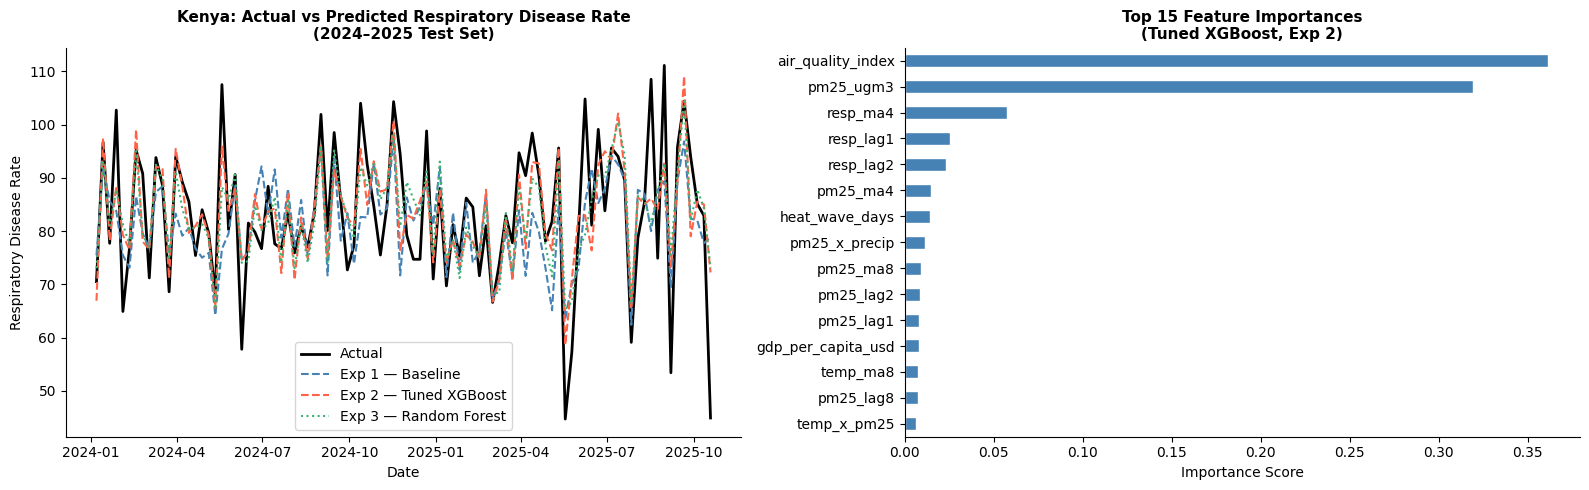


Summary:
  Exp 1 Baseline  — Global R²: 0.571  |  Kenya R²: 0.317
  Exp 2 XGBoost   — Global R²: 0.755  |  Kenya R²: 0.586
  Exp 3 Rand Forest— Global R²: 0.701  |  Kenya R²: 0.524


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Kenya: Actual vs all three predictions
ken_plot = test_kenya.sort_values('date')
axes[0].plot(ken_plot['date'].values, y_ken.values,
             label='Actual', linewidth=2, color='black')
axes[0].plot(ken_plot['date'].values, model_b.predict(X_ken[baseline_features]),
             label='Exp 1 — Baseline',       linewidth=1.5, linestyle='--', color='steelblue')
axes[0].plot(ken_plot['date'].values, model_t.predict(X_ken),
             label='Exp 2 — Tuned XGBoost',  linewidth=1.5, linestyle='--', color='tomato')
axes[0].plot(ken_plot['date'].values, model_rf.predict(X_ken),
             label='Exp 3 — Random Forest',  linewidth=1.5, linestyle=':',  color='mediumseagreen')
axes[0].set_title(f'{COUNTRY_NAME}: Actual vs Predicted Respiratory Disease Rate\n(2024–2025 Test Set)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Respiratory Disease Rate')
axes[0].legend()

# Feature importance — best XGBoost model
importances = pd.Series(model_t.feature_importances_, index=feature_cols)\
    .sort_values(ascending=True).tail(15)
importances.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Top 15 Feature Importances\n(Tuned XGBoost, Exp 2)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('fig_model_results.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\nSummary:')
print(f'  Exp 1 Baseline  — Global R²: {r2_b:.3f}  |  {COUNTRY_NAME} R²: {r2_bk:.3f}')
print(f'  Exp 2 XGBoost   — Global R²: {r2_t:.3f}  |  {COUNTRY_NAME} R²: {r2_tk:.3f}')
print(f'  Exp 3 Rand Forest— Global R²: {r2_rf:.3f}  |  {COUNTRY_NAME} R²: {r2_rfk:.3f}')


### Model Results: Predictions & Feature Importance

This final cell produces two visualisations that summarise the overall modelling results.

**Left plot - Actual vs Predicted (Kenya, 2024–2025):**
All three models are plotted against the actual respiratory disease rate for Kenya on the test set. This allows direct visual comparison of how closely each model tracks the real values. A model that closely follows the black actual line across the full date range is generalising well to Kenya specifically - not just performing well on the global test set.

**Right plot - Feature Importance (Tuned XGBoost):**
Shows the top 15 features ranked by how much they contributed to reducing prediction error across the XGBoost trees. Features further to the right were relied on more heavily by the model. This chart validates the feature engineering decisions made earlier - if `resp_lag1`, `resp_lag2`, and `country_encoded` appear at the top, it confirms that the strongest predictors of this week's respiratory disease rate are last week's rate and the country context, which is consistent with the correlation analysis in Task 1B.

**summary:**
The R² scores printed at the bottom give a clean numerical comparison across all three experiments, both globally and for Kenya specifically. The difference between Experiment 1 and Experiment 2 quantifies the value added by the full feature engineering pipeline - autoregressive lags, moving averages, country encoding, seasonal features, and interaction terms. The difference between Experiment 2 and Experiment 3 shows whether XGBoost or Random Forest is better suited to this dataset.